In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

In [125]:
path = "../data/processed_data.csv"
df = pd.read_csv(path)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Shape: {df.shape}, NaNs: {df.isna().sum().sum()}")
df.head()

Shape: (1470, 37), NaNs: 0


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,YearsWithCurrManager,RemoteWork,MonthlyIncome,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,StressRating
0,0.448696,2.275186,0.590048,1.401512,-1.013529,-0.888082,-0.938496,-0.660531,-1.231716,1.383138,...,0.245533,-1.484408,-0.859256,-1.326566,-1.216109,-0.645124,-0.581016,-1.107823,-1.162892,4
1,1.323184,-0.439525,-0.913194,-0.493817,-0.152180,-1.863778,-0.938496,0.254625,0.811876,-0.240677,...,0.805990,0.142795,-0.029982,1.326566,0.822295,-0.645124,-0.581016,0.902671,-1.162892,2
2,0.011452,2.275186,0.590048,-0.493817,-0.890479,-0.888082,1.318192,1.169781,0.811876,1.284725,...,-1.155608,-0.670806,0.348985,-0.442189,0.822295,-0.645124,-0.581016,-1.107823,-1.162892,3
3,-0.425792,-0.439525,-0.913194,-0.493817,-0.767430,1.063309,-0.938496,1.169781,-1.231716,-0.486709,...,-1.155608,-0.670806,2.187149,1.326566,0.822295,1.550090,1.721123,0.902671,-1.162892,1
4,-1.081659,-0.439525,0.590048,-0.493817,-0.890479,-1.863778,0.565963,-1.575686,0.811876,-1.274014,...,-0.595151,-0.670806,-1.969845,-0.442189,-1.216109,-0.645124,-0.581016,-1.107823,0.943641,3


In [126]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.0001, n_iterations=100000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        m, n = X.shape
        self.coef_ = np.zeros((n, 1)) if y.ndim == 2 else np.zeros(n)
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = self.predict(X)
            residual = y_pred - y
            intercept_gradient = (2/m) * np.sum(residual)
            coef_gradient = (2/m) * np.dot(X.T, residual)
            intercept_gradient = np.clip(intercept_gradient, -1e6, 1e6)
            coef_gradient = np.clip(coef_gradient, -1e6, 1e6)
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient
            if np.any(np.isnan(self.coef_)) or np.isnan(self.intercept_):
                break

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_


class GradientBoostingRegressorFromScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None
        
    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.initial_prediction = np.mean(y)
        predictions = np.full_like(y, self.initial_prediction, dtype=float).flatten()
        
        for i in range(self.n_estimators):
            residuals = y.flatten() - predictions
            weak_learner = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
            weak_learner.fit(X, residuals.reshape(-1, 1))
            weak_pred = weak_learner.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
            self.trees.append(weak_learner)
    
    def predict(self, X):
        predictions = np.full(X.shape[0], self.initial_prediction, dtype=float)
        for tree in self.trees:
            weak_pred = tree.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
        return predictions

In [127]:
target = 'StressRating'
corrs = df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
best_feature = corrs.index[0]

X = df.drop(columns=[target])
y = df[target].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
def train_and_evaluate(model, X_train_data, X_test_data, y_train_data, y_test_data):
    """Train model and calculate metrics."""
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)
    return {'mse': mse, 'rmse': rmse, 'r2': r2, 'y_pred': y_pred}

def plot_prediction(ax, y_actual_sorted, y_pred, color, title, target_var):
    """Plot actual vs predicted on given axes."""
    sort_idx = np.argsort(y_actual_sorted.flatten())
    y_pred_sorted = y_pred.flatten()[sort_idx]
    y_act_sorted = y_actual_sorted.flatten()[sort_idx]
    ax.plot(range(len(y_act_sorted)), y_act_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, markersize=3, alpha=0.7, label='Predicted')
    ax.fill_between(range(len(y_act_sorted)), y_act_sorted, y_pred_sorted, alpha=0.15, color='gray')
    ax.set(xlabel="Sample", ylabel=target_var, title=title)
    ax.legend()

def plot_comparison(axes_list, y_actual, predictions_dict, y_test_data, target_name):
    """Generic comparison plotter for 2+ subplots."""
    sort_idx = y_test_data.flatten().argsort()
    y_actual_sorted = y_test_data.flatten()[sort_idx]
    
    colors = ['#FF5722', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
    for ax_idx, (name, (y_pred, color), title) in enumerate(zip(predictions_dict.keys(), 
                                                                   zip(predictions_dict.values(), colors), 
                                                                   predictions_dict.keys())):
        if ax_idx >= len(axes_list.flat):
            break
        ax = axes_list.flat[ax_idx]
        y_pred_sorted = y_pred.flatten()[sort_idx]
        ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', 
                markersize=3, alpha=0.7, label='Actual')
        ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, 
                markersize=3, alpha=0.7, label='Predicted')
        ax.fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_sorted, alpha=0.15)
        ax.set(xlabel="Sample", ylabel=target_name)
        ax.legend()

In [129]:
# Simple Linear Regression: Best single feature
X_train_simple = X_train[[best_feature]].values
X_test_simple = X_test[[best_feature]].values

model_simple_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_simple_lib = LinearRegression()

results_simple = {
    'From Scratch': train_and_evaluate(model_simple_scratch, X_train_simple, X_test_simple, y_train, y_test),
    'Sklearn': train_and_evaluate(model_simple_lib, X_train_simple, X_test_simple, y_train, y_test)
}

r2_simple_scratch = results_simple['From Scratch']['r2']
r2_simple_lib = results_simple['Sklearn']['r2']
y_pred_simple_scratch = results_simple['From Scratch']['y_pred']
y_pred_simple_lib = results_simple['Sklearn']['y_pred']

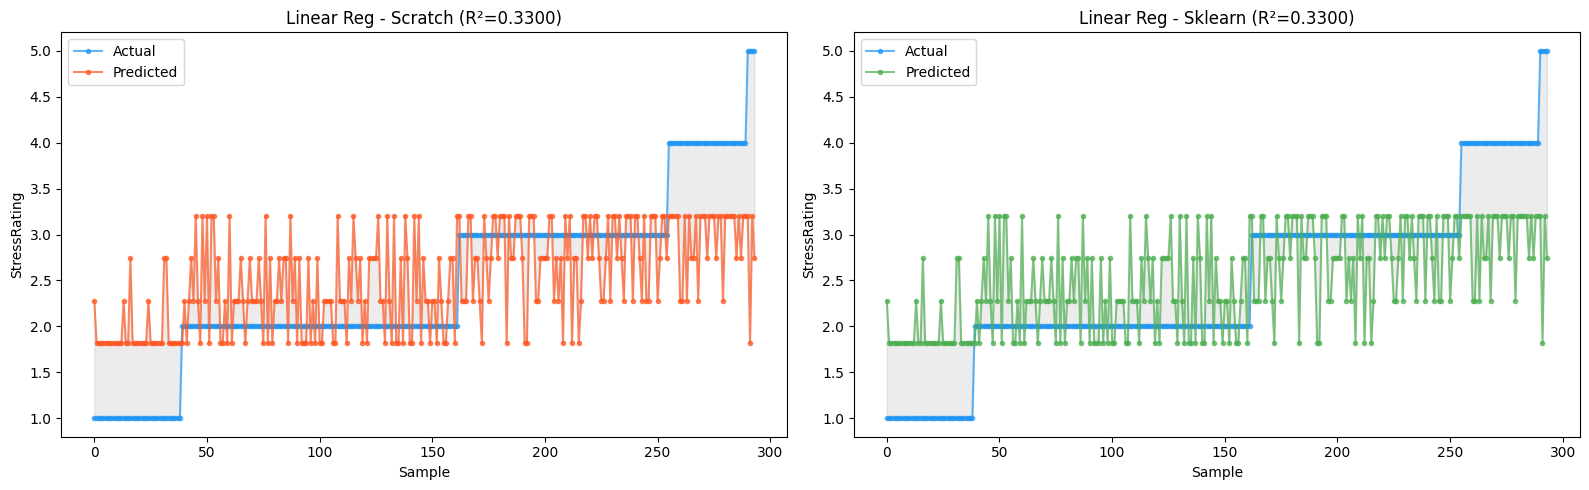

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

for ax, key, color, title_suffix in zip(axes, ['From Scratch', 'Sklearn'], ['#FF5722', '#4CAF50'], ['Scratch', 'Sklearn']):
    y_pred = results_simple[key]['y_pred']
    r2_val = results_simple[key]['r2']
    plot_prediction(ax, y_actual_sorted, y_pred, color, f"Linear Reg - {title_suffix} (R²={r2_val:.4f})", target)

plt.tight_layout()
plt.show()

In [131]:
var_ratio = 0.95
pca = PCA(n_components=var_ratio)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
n_comp = pca.n_components_

model_pca = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
pca_results = train_and_evaluate(model_pca, X_train_pca, X_test_pca, y_train, y_test)
mse_pca = pca_results['mse']
r2_pca = pca_results['r2']
y_pred_pca = pca_results['y_pred']

results_pca = {f"PCA {int(var_ratio*100)}%": {
    'n_components': n_comp, 'mse': mse_pca,
    'rmse': pca_results['rmse'], 'r2': r2_pca, 'y_pred': y_pred_pca
}}

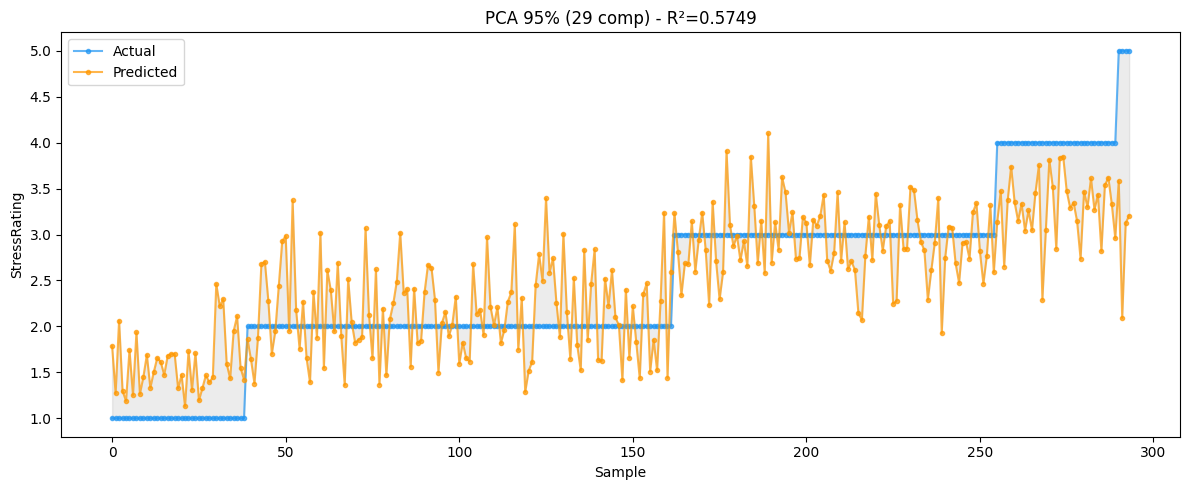

In [132]:
fig, ax = plt.subplots(figsize=(12, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]
plot_prediction(ax, y_actual_sorted, y_pred_pca, '#FF9800', f"PCA 95% ({n_comp} comp) - R²={r2_pca:.4f}", target)
plt.tight_layout()
plt.show()

In [ ]:
# Gradient Boosting
y_train_gb = y_train.flatten()
model_gb_scratch = GradientBoostingRegressorFromScratch(n_estimators=100, learning_rate=0.1, random_state=42)
model_gb_lib = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

gb_scratch_res = train_and_evaluate(model_gb_scratch, X_train, X_test, y_train_gb, y_test)
gb_lib_res = train_and_evaluate(model_gb_lib, X_train, X_test, y_train_gb, y_test)

y_pred_gb_scratch = gb_scratch_res['y_pred'].reshape(-1, 1)
y_pred_gb_lib = gb_lib_res['y_pred'].reshape(-1, 1)
r2_gb_scratch, r2_gb_lib = gb_scratch_res['r2'], gb_lib_res['r2']
mse_gb_scratch, mse_gb_lib = gb_scratch_res['mse'], gb_lib_res['mse']
rmse_gb_scratch, rmse_gb_lib = gb_scratch_res['rmse'], gb_lib_res['rmse']

results_gb = {
    'Gradient Boosting - From Scratch': {'n_features': X_train.shape[1], **gb_scratch_res},
    'Gradient Boosting - Sklearn': {'n_features': X_train.shape[1], **gb_lib_res}
}

# Gaussian Process
scaler_gp = StandardScaler()
X_train_gp = scaler_gp.fit_transform(X_train)
X_test_gp = scaler_gp.transform(X_test)
y_train_gp = y_train.flatten()
model_gp = GaussianProcessRegressor(kernel=C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)), 
                                   n_restarts_optimizer=9, alpha=1e-6, random_state=42)

gp_res = train_and_evaluate(model_gp, X_train_gp, X_test_gp, y_train_gp, y_test)
y_pred_gp = gp_res['y_pred'].reshape(-1, 1)
_, y_std_gp = model_gp.predict(X_test_gp, return_std=True)
r2_gp, mse_gp, rmse_gp = gp_res['r2'], gp_res['mse'], gp_res['rmse']

results_gp = {
    'Gaussian Process': {'n_features': X_train.shape[1], **gp_res}
}

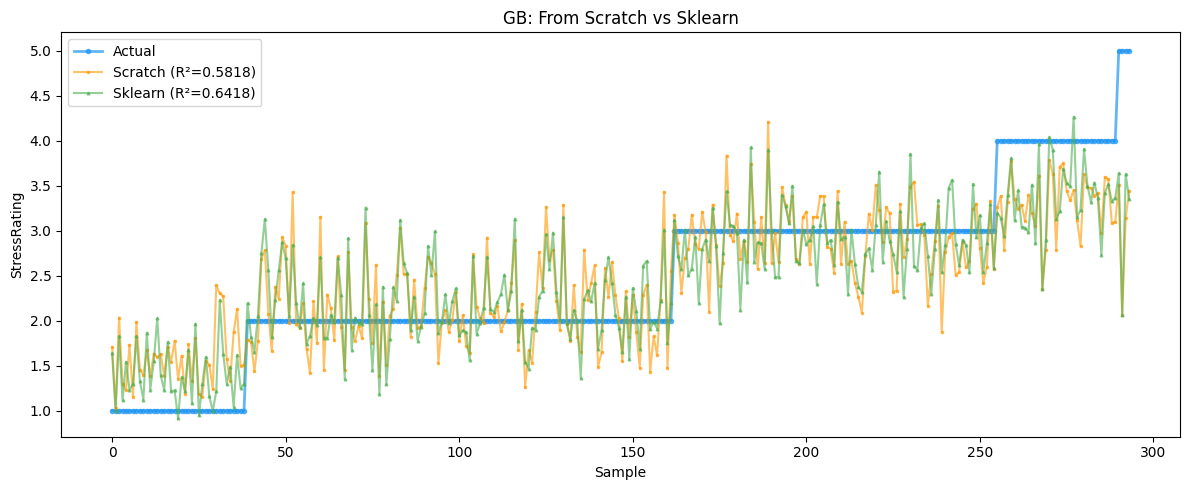

In [136]:
fig, ax = plt.subplots(figsize=(12, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# GB comparison overlay
ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual', linewidth=2)
ax.plot(range(len(y_pred_gb_scratch.flatten()[sort_idx])), y_pred_gb_scratch.flatten()[sort_idx], 's-', color='#FF9800', markersize=2, alpha=0.6, label=f'Scratch (R²={r2_gb_scratch:.4f})')
ax.plot(range(len(y_pred_gb_lib.flatten()[sort_idx])), y_pred_gb_lib.flatten()[sort_idx], '^-', color='#4CAF50', markersize=2, alpha=0.6, label=f'Sklearn (R²={r2_gb_lib:.4f})')
ax.set(xlabel="Sample", ylabel=target, title="GB: From Scratch vs Sklearn")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Polynomial Regression: Degree 2, Top 15 features
top_features = corrs.head(15).index.tolist()
X_train_poly_base = X_train[top_features].values
X_test_poly_base = X_test[top_features].values

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_poly_base)
X_test_poly = poly.transform(X_test_poly_base)

model_poly_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_poly_lib = LinearRegression()

poly_scratch_res = train_and_evaluate(model_poly_scratch, X_train_poly, X_test_poly, y_train, y_test)
poly_lib_res = train_and_evaluate(model_poly_lib, X_train_poly, X_test_poly, y_train, y_test)

y_pred_poly_scratch = poly_scratch_res['y_pred']
y_pred_poly_lib = poly_lib_res['y_pred']
r2_poly_scratch, r2_poly_lib = poly_scratch_res['r2'], poly_lib_res['r2']
mse_poly_scratch, mse_poly_lib = poly_scratch_res['mse'], poly_lib_res['mse']
rmse_poly_scratch, rmse_poly_lib = poly_scratch_res['rmse'], poly_lib_res['rmse']

results_poly = {
    'Poly Deg 2 - From Scratch': poly_scratch_res,
    'Poly Deg 2 - Sklearn': poly_lib_res
}

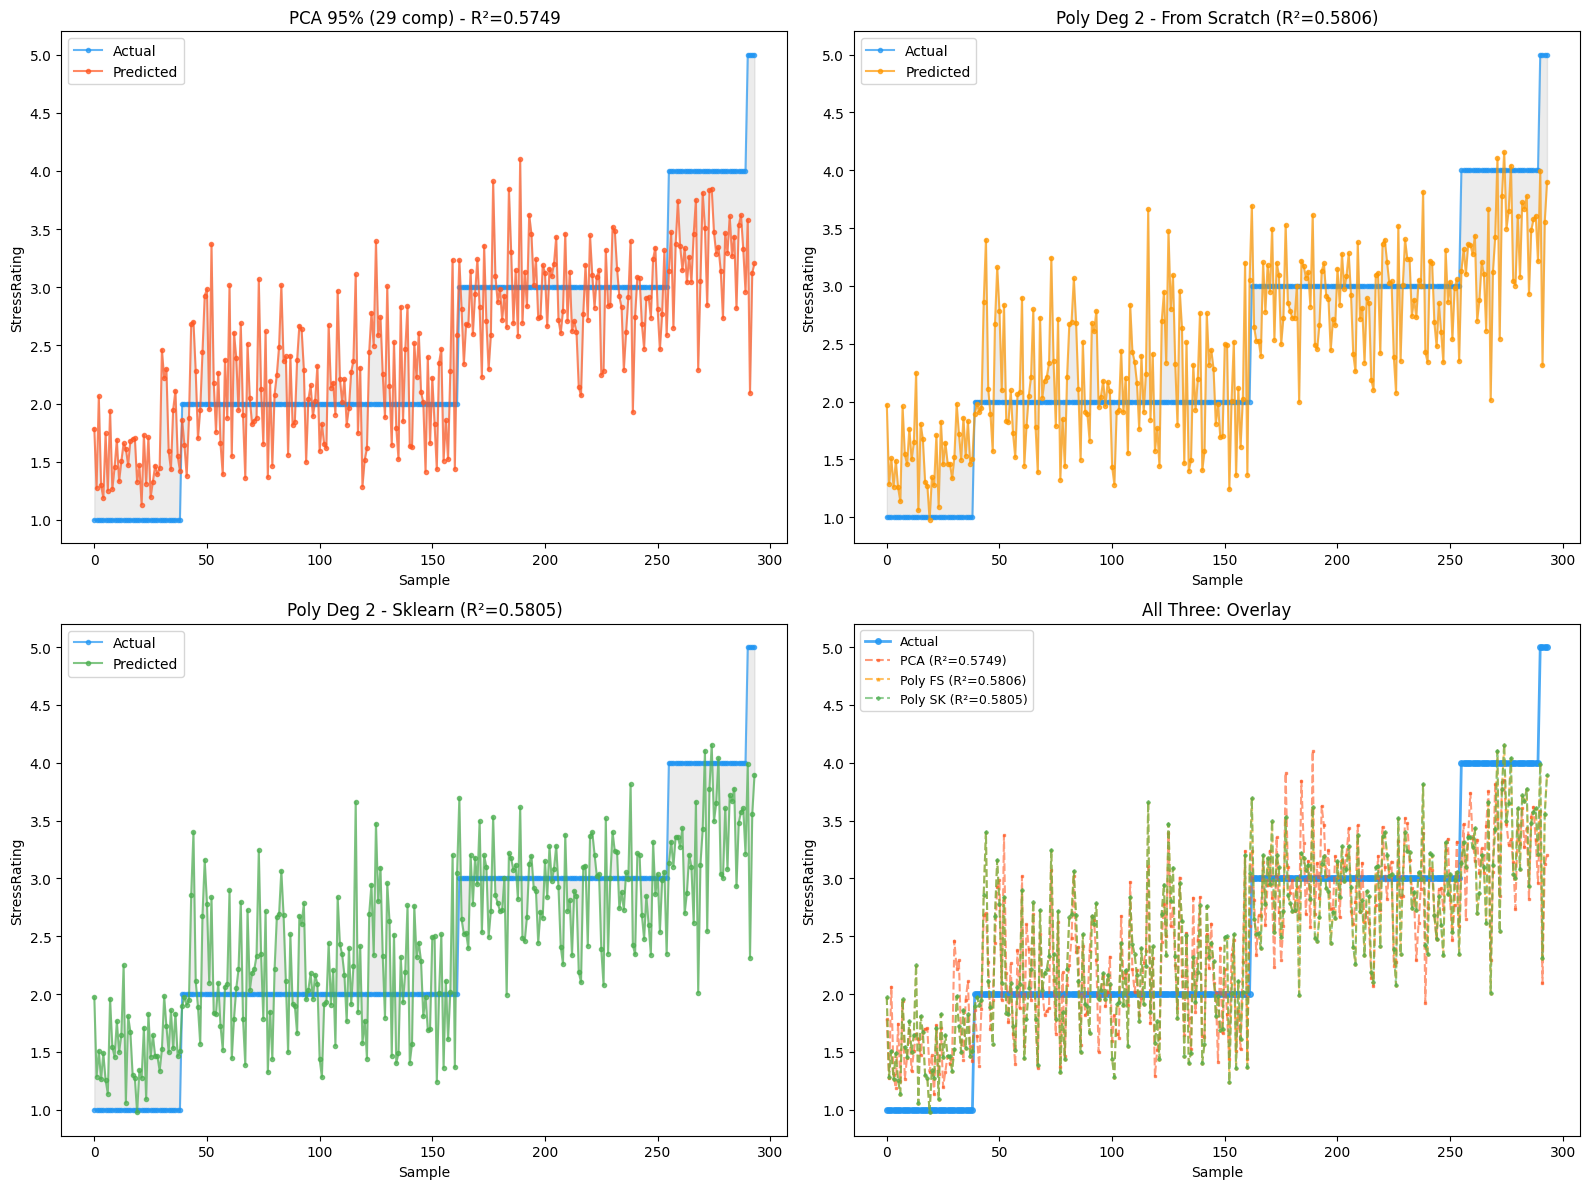

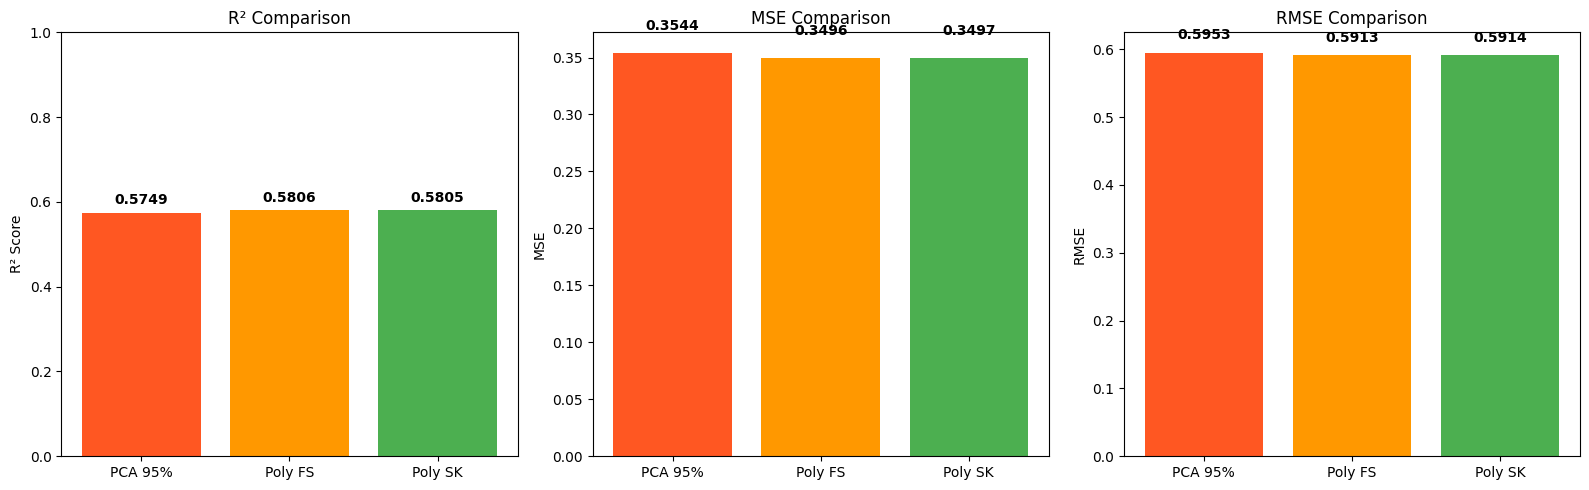

In [137]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# Define plots: (data, color, title)
plots = [
    (y_pred_pca, '#FF5722', f"PCA 95% ({n_comp} comp) - R²={r2_pca:.4f}"),
    (y_pred_poly_scratch, '#FF9800', f"Poly Deg 2 - From Scratch (R²={r2_poly_scratch:.4f})"),
    (y_pred_poly_lib, '#4CAF50', f"Poly Deg 2 - Sklearn (R²={r2_poly_lib:.4f})")
]

for i, (y_pred_data, color, title) in enumerate(plots):
    ax = axes[i // 2, i % 2]
    y_pred_sorted = y_pred_data.flatten()[sort_idx]
    ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, markersize=3, alpha=0.7, label='Predicted')
    ax.fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_sorted, alpha=0.15, color='gray')
    ax.set(xlabel="Sample", ylabel=target, title=title)
    ax.legend()

# Overlay plot in 4th subplot
ax = axes[1, 1]
ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=4, alpha=0.8, label='Actual', linewidth=2)
ax.plot(range(len(y_pred_pca.flatten()[sort_idx])), y_pred_pca.flatten()[sort_idx], 's--', color='#FF5722', markersize=2, alpha=0.6, label=f'PCA (R²={r2_pca:.4f})')
ax.plot(range(len(y_pred_poly_scratch.flatten()[sort_idx])), y_pred_poly_scratch.flatten()[sort_idx], '^--', color='#FF9800', markersize=2, alpha=0.6, label=f'Poly FS (R²={r2_poly_scratch:.4f})')
ax.plot(range(len(y_pred_poly_lib.flatten()[sort_idx])), y_pred_poly_lib.flatten()[sort_idx], 'D--', color='#4CAF50', markersize=2, alpha=0.6, label=f'Poly SK (R²={r2_poly_lib:.4f})')
ax.set(xlabel="Sample", ylabel=target, title="All Three: Overlay")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Metric comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = ['PCA 95%', 'Poly FS', 'Poly SK']
r2_scores = [r2_pca, r2_poly_scratch, r2_poly_lib]
mse_scores = [mse_pca, mse_poly_scratch, mse_poly_lib]
rmse_scores = [np.sqrt(mse_pca), rmse_poly_scratch, rmse_poly_lib]
colors = ['#FF5722', '#FF9800', '#4CAF50']

for ax, scores, ylabel, title in zip(axes, [r2_scores, mse_scores, rmse_scores], ['R² Score', 'MSE', 'RMSE'], ['R² Comparison', 'MSE Comparison', 'RMSE Comparison']):
    bars = ax.bar(models, scores, color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylabel == 'R² Score':
        ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

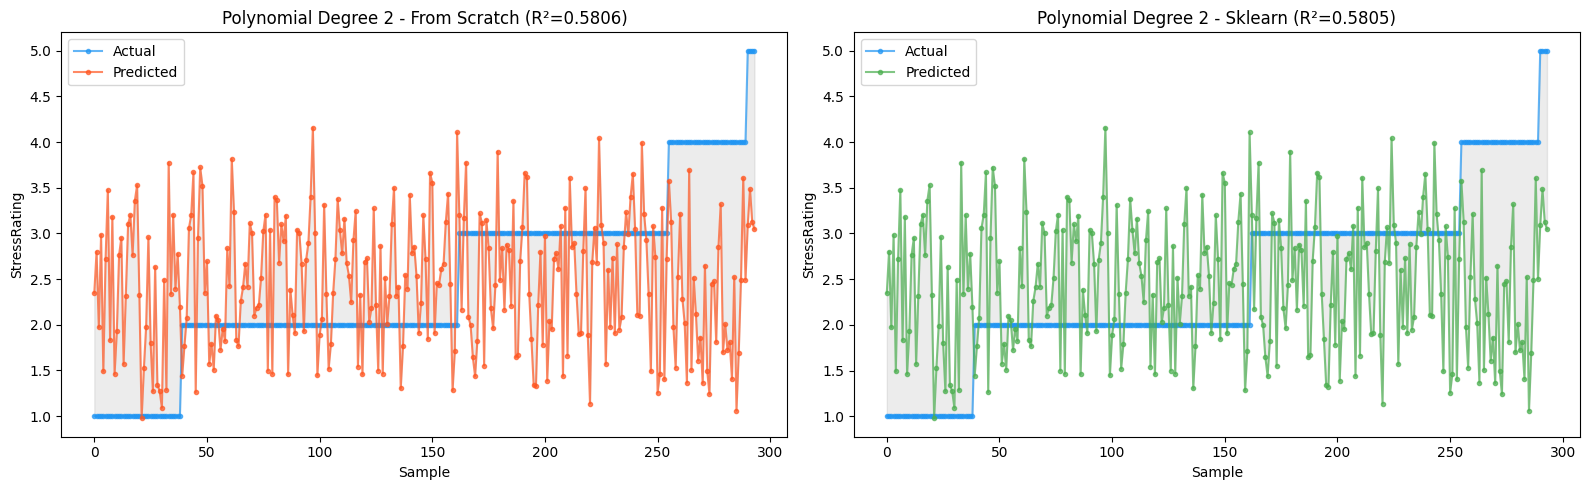

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

poly_data = [(y_pred_poly_scratch, '#FF5722', 'From Scratch', r2_poly_scratch),
             (y_pred_poly_lib, '#4CAF50', 'Sklearn', r2_poly_lib)]
for ax, (y_pred, color, label, r2_val) in zip(axes, poly_data):
    plot_prediction(ax, y_actual_sorted, y_pred, color, f"Polynomial Degree {degree} - {label} (R²={r2_val:.4f})", target)

plt.tight_layout()
plt.show()

=== MODEL COMPARISON SUMMARY ===

                                     Model  Features      MSE     RMSE       R²
Simple LR (WelfareBenefits) - From Scratch         1 0.558536 0.747352 0.329999
     Simple LR (WelfareBenefits) - Sklearn         1 0.558536 0.747352 0.329999
                             PCA - PCA 95%        29 0.354398 0.595313 0.574876
                 Poly Deg 2 - From Scratch         1 0.349631 0.591296 0.580594
                      Poly Deg 2 - Sklearn         1 0.349696 0.591351 0.580516
          Gradient Boosting - From Scratch        36 0.348654 0.590469 0.581766
               Gradient Boosting - Sklearn        36 0.298649 0.546488 0.641750

Best: Gradient Boosting - Sklearn (R² = 0.6418)


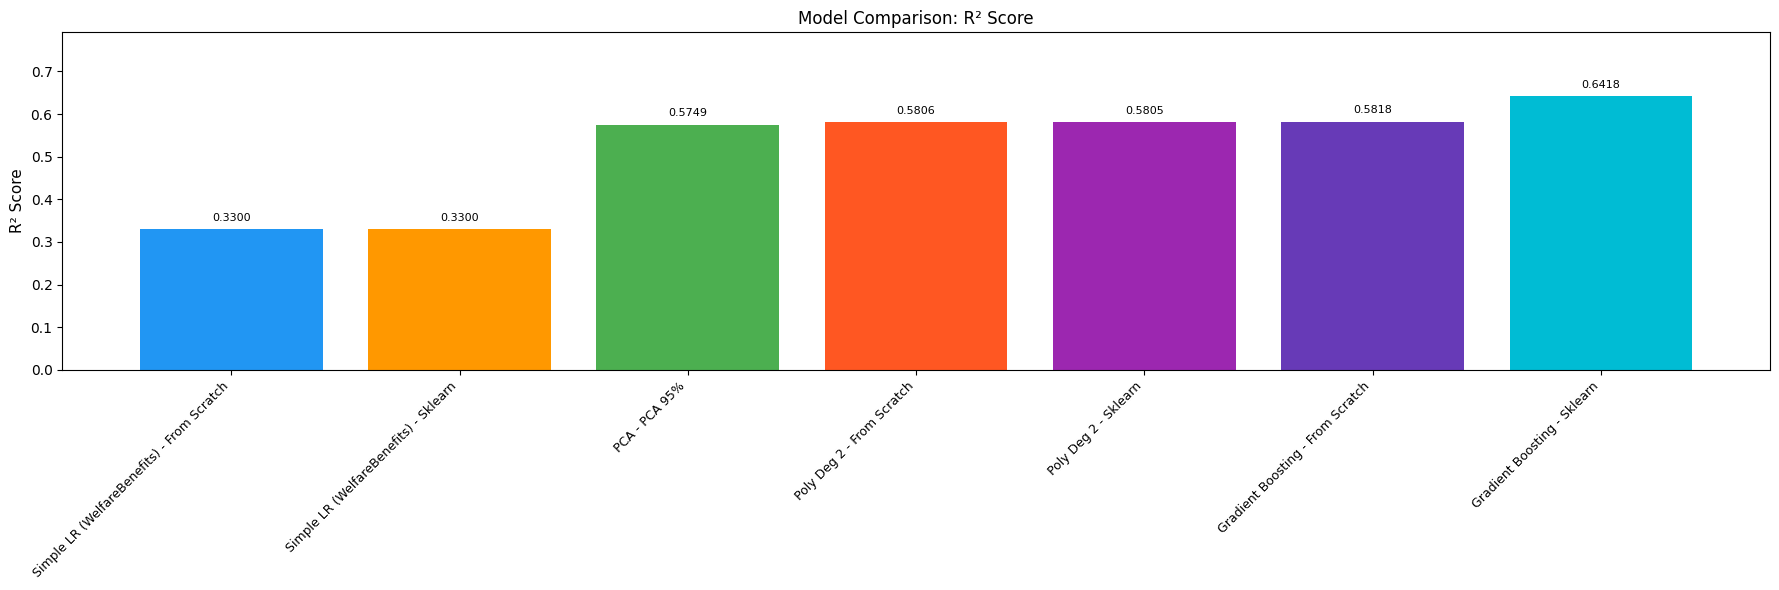


=== FROM SCRATCH vs LIBRARY ===
Linear Reg           Scratch R²=0.3300  vs  Sklearn R²=0.3300  Δ=0.0000
Polynomial           Scratch R²=0.5806  vs  Sklearn R²=0.5805  Δ=0.0001
Gradient Boost       Scratch R²=0.5818  vs  Sklearn R²=0.6418  Δ=0.0600


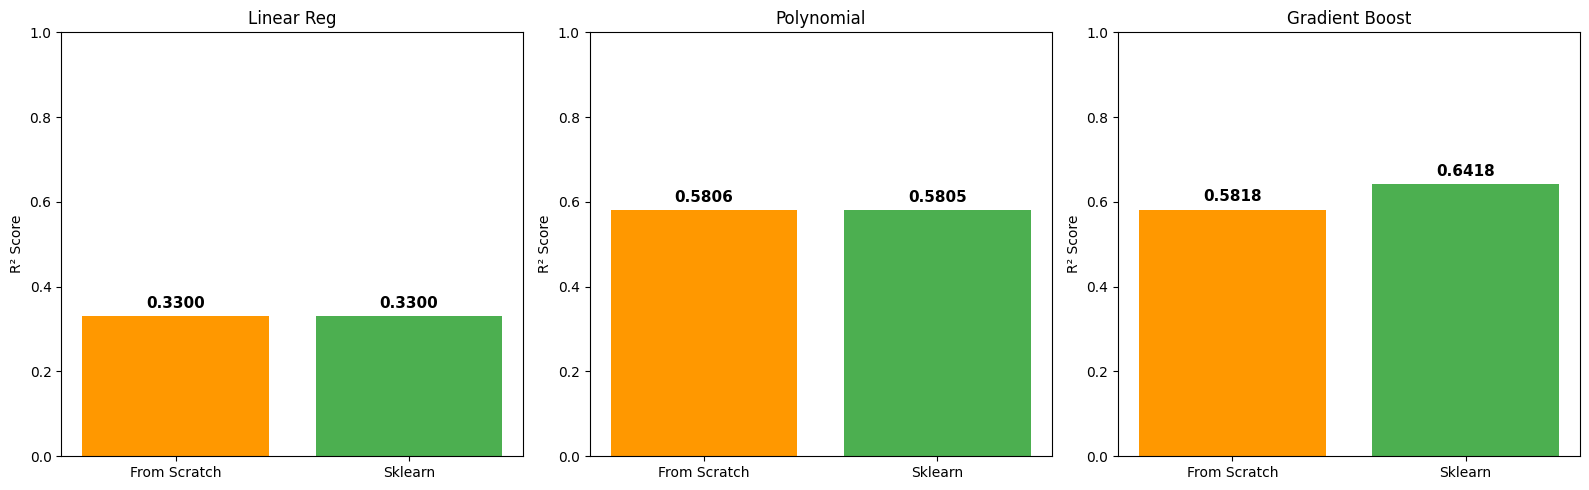

In [138]:

# Build summary data from all results dictionaries
results_collection = [
    (results_simple, lambda x: f"Simple LR ({best_feature}) - {x}"),
    (results_pca, lambda x: f"PCA - {x}"),
    (results_poly, lambda x: x),
    (results_gb, lambda x: x),
]

summary_data = []
for results_dict, label_fn in results_collection:
    for model_label, res in results_dict.items():
        model_name = label_fn(model_label)
        n_features = res.get('n_features', res.get('n_components', 1))
        summary_data.append({
            'Model': model_name,
            'Features': n_features,
            'MSE': res['mse'],
            'RMSE': res['rmse'],
            'R²': res['r2']
        })

summary_df = pd.DataFrame(summary_data)
print("=== MODEL COMPARISON SUMMARY ===\n")
print(summary_df.to_string(index=False))
best_idx = summary_df['R²'].idxmax()
print(f"\nBest: {summary_df.loc[best_idx, 'Model']} (R² = {summary_df.loc[best_idx, 'R²']:.4f})")

# Overall model comparison
fig, ax = plt.subplots(figsize=(18, 6))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#FF5722', '#9C27B0', '#673AB7', '#00BCD4']
bars = ax.bar(range(len(summary_df)), summary_df['R²'], color=colors[:len(summary_df)])
ax.set_xticks(range(len(summary_df)))
ax.set_xticklabels(summary_df['Model'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Model Comparison: R² Score', fontsize=12)
ax.set_ylim(0, min(1.0, summary_df['R²'].max() + 0.15))
for bar, val in zip(bars, summary_df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# From-scratch vs library comparison
print("\n=== FROM SCRATCH vs LIBRARY ===")
comparison_pairs = [
    ('Linear Reg', r2_simple_scratch, r2_simple_lib),
    ('Polynomial', r2_poly_scratch, r2_poly_lib),
    ('Gradient Boost', r2_gb_scratch, r2_gb_lib)
]

for name, scratch_r2, lib_r2 in comparison_pairs:
    print(f"{name:20} Scratch R²={scratch_r2:.4f}  vs  Sklearn R²={lib_r2:.4f}  Δ={abs(lib_r2 - scratch_r2):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, scratch_r2, lib_r2) in zip(axes, comparison_pairs):
    r2_vals = [scratch_r2, lib_r2]
    bars = ax.bar(['From Scratch', 'Sklearn'], r2_vals, color=['#FF9800', '#4CAF50'])
    ax.set_ylabel('R² Score')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
